# Phase 2: Chapman Chemistry Verification

Verifies MPAS + MICM Chapman chemistry on the 480-km JW baroclinic wave test.

Key checks:
1. **Diurnal cycle** — O₃ and atomic O follow the sun: production while illuminated, plateau at night
2. **Day / night contrast** — spatial O₃ map shows higher concentrations on the dayside
3. **Odd-oxygen budget** — global Ox (= O₃ + O + O(¹D)) rises from zero as O₂ photolysis creates new odd oxygen; nightside single-column Ox stays nearly constant (no source, only slight advective drift)

**Pre-requisite:** `data/jw_480km_chapman/output.nc`

In [ ]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data" / "jw_480km_chapman"
OUTPUT = DATA_DIR / "output.nc"
assert OUTPUT.exists(), f"Run the JW test first — {OUTPUT} not found"

ds = nc.Dataset(OUTPUT)
lat = np.degrees(ds["latCell"][:])
lon = np.degrees(ds["lonCell"][:])
nTimes = ds.dimensions["Time"].size
nCells = ds.dimensions["nCells"].size
nLev = ds.dimensions["nVertLevels"].size

# Identify representative equatorial cells on opposite sides of the planet
equator = np.abs(lat) < 15
subsolar_idx = np.where(equator & (np.abs(lon) < 15))[0][0]
antisolar_idx = np.where(equator & (np.abs(lon - 180) < 30))[0]
if len(antisolar_idx) == 0:
    antisolar_idx = np.where(equator & (np.abs(lon + 180) < 30))[0]
antisolar_idx = antisolar_idx[0]

LEV = 20  # lower stratosphere — strongest Chapman signal
hours = np.arange(nTimes)

print(f"Grid: {nCells} cells, {nLev} levels, {nTimes} hourly snapshots")
print(f"Subsolar cell:  lat={lat[subsolar_idx]:.1f}°, lon={lon[subsolar_idx]:.1f}°")
print(f"Antisolar cell: lat={lat[antisolar_idx]:.1f}°, lon={lon[antisolar_idx]:.1f}°")

Grid: 2562 cells, 26 levels, 25 hourly snapshots
Subsolar cell:  lat=0.0°, lon=-13.0°
Antisolar cell: lat=-0.0°, lon=167.0°


## 1. Diurnal Cycle — Single-Column Time Series

O₃ builds up while the column is sunlit (photolysis of O₂ → 2 O, then O + O₂ → O₃).
When the column enters night, atomic O and O(¹D) drop to zero and O₃ plateaus.
The subsolar (lon ≈ 0°) and antisolar (lon ≈ 180°) cells are roughly 12 h out of phase.

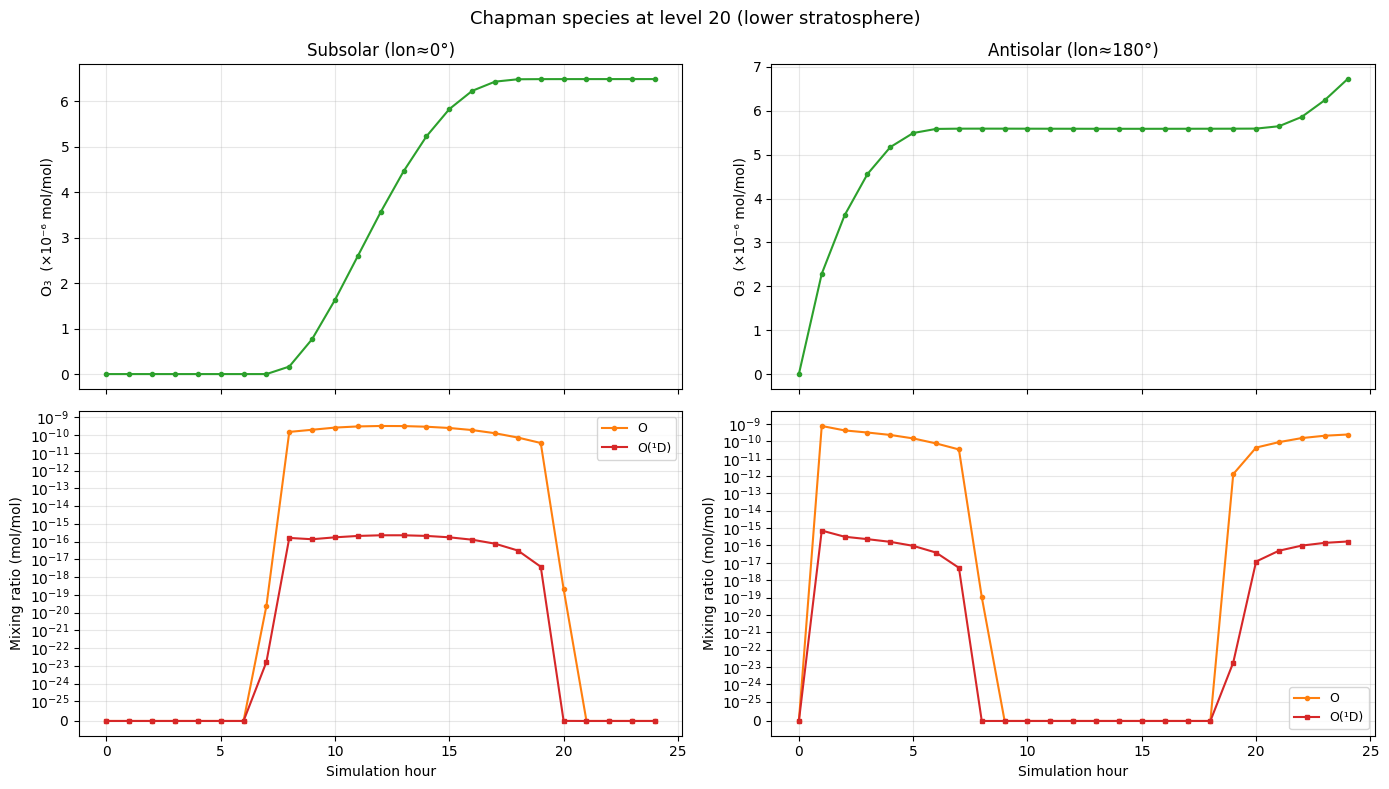

CHECK 1 — Subsolar nighttime O3 drift: 0.0081% (expect < 1%)
  PASS ✓


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for col, (cidx, label) in enumerate([(subsolar_idx, "Subsolar (lon≈0°)"),
                                      (antisolar_idx, "Antisolar (lon≈180°)")]):
    o3 = np.array([ds["o3"][t, cidx, LEV] for t in range(nTimes)])
    o  = np.array([ds["o"][t, cidx, LEV]  for t in range(nTimes)])
    o1d = np.array([ds["o1d"][t, cidx, LEV] for t in range(nTimes)])

    # Top row: O3
    ax = axes[0, col]
    ax.plot(hours, o3 * 1e6, "o-", ms=3, color="tab:green")
    ax.set_ylabel("O₃  (×10⁻⁶ mol/mol)")
    ax.set_title(label)
    ax.grid(alpha=0.3)

    # Bottom row: O and O1D (log scale)
    ax = axes[1, col]
    ax.plot(hours, o, "o-", ms=3, label="O", color="tab:orange")
    ax.plot(hours, o1d, "s-", ms=3, label="O(¹D)", color="tab:red")
    ax.set_yscale("symlog", linthresh=1e-25)
    ax.set_ylabel("Mixing ratio (mol/mol)")
    ax.set_xlabel("Simulation hour")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(f"Chapman species at level {LEV} (lower stratosphere)", fontsize=13)
fig.tight_layout()
plt.show()

# CHECK: subsolar O3 should plateau at night (last 4 hours)
night_o3 = np.array([ds["o3"][t, subsolar_idx, LEV] for t in range(20, 25)])
drift = (night_o3.max() - night_o3.min()) / night_o3.mean()
print(f"CHECK 1 — Subsolar nighttime O3 drift: {drift:.4%} (expect < 1%)")
assert drift < 0.01, f"Nighttime O3 drift too large: {drift:.4%}"
print("  PASS ✓")

## 2. Spatial Day / Night O₃ Contrast

At a late time step the illuminated hemisphere should have distinctly
higher O₃ than the dark hemisphere.  We plot the last snapshot (t = 24 h).

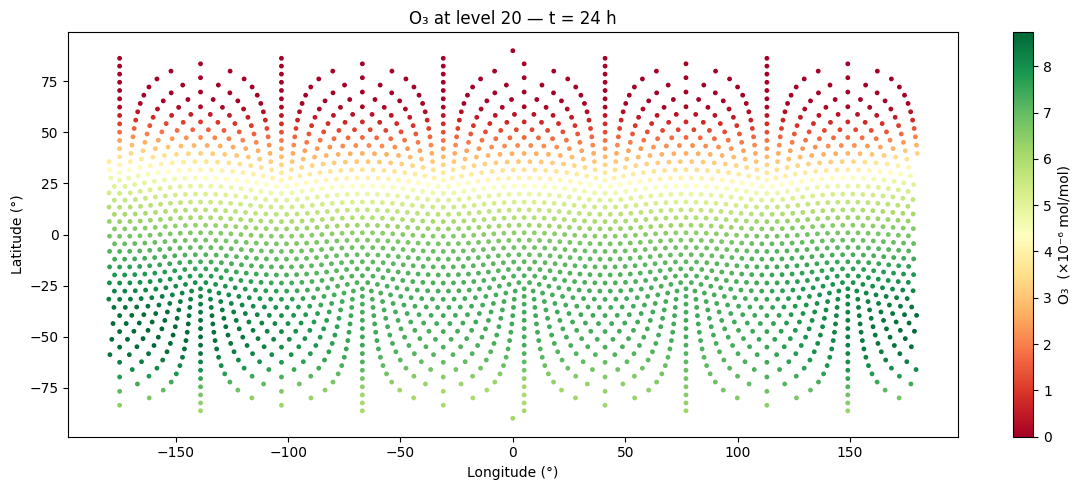

CHECK 2 — SH mean O₃ (lat < -30°): 7.567e-06, NH mean (lat > 30°): 1.691e-06
          SH/NH ratio: 4.47 (expect > 1 — Jan 1 sun favours southern hemisphere)
  PASS ✓


In [4]:
t_last = nTimes - 1
o3_map = ds["o3"][t_last, :, LEV]

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(lon, lat, c=o3_map * 1e6, s=6, cmap="RdYlGn")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
ax.set_title(f"O₃ at level {LEV} — t = {t_last} h")
plt.colorbar(sc, ax=ax, label="O₃  (×10⁻⁶ mol/mol)")
fig.tight_layout()
plt.show()

# CHECK: southern hemisphere (more sunlit at Jan 1) should have higher O3
sh_mean = o3_map[lat < -30].mean()
nh_mean = o3_map[lat > 30].mean()
ratio = sh_mean / nh_mean if nh_mean > 0 else float("inf")
print(f"CHECK 2 — SH mean O₃ (lat < -30°): {sh_mean:.3e}, NH mean (lat > 30°): {nh_mean:.3e}")
print(f"          SH/NH ratio: {ratio:.2f} (expect > 1 — Jan 1 sun favours southern hemisphere)")
assert ratio > 1.0, f"No latitudinal contrast: ratio = {ratio:.2f}"
print("  PASS ✓")

## 3. Odd-Oxygen Budget

**Global Ox (= O₃ + O + O(¹D))** should rise steadily from zero because O₂
photolysis is a net source of odd oxygen. Chapman chemistry only *interconverts*
Ox members — it doesn't create or destroy the family.

**Nightside column Ox** should stay approximately constant once photolysis shuts
off, with small drift from advection moving air in/out of the column.

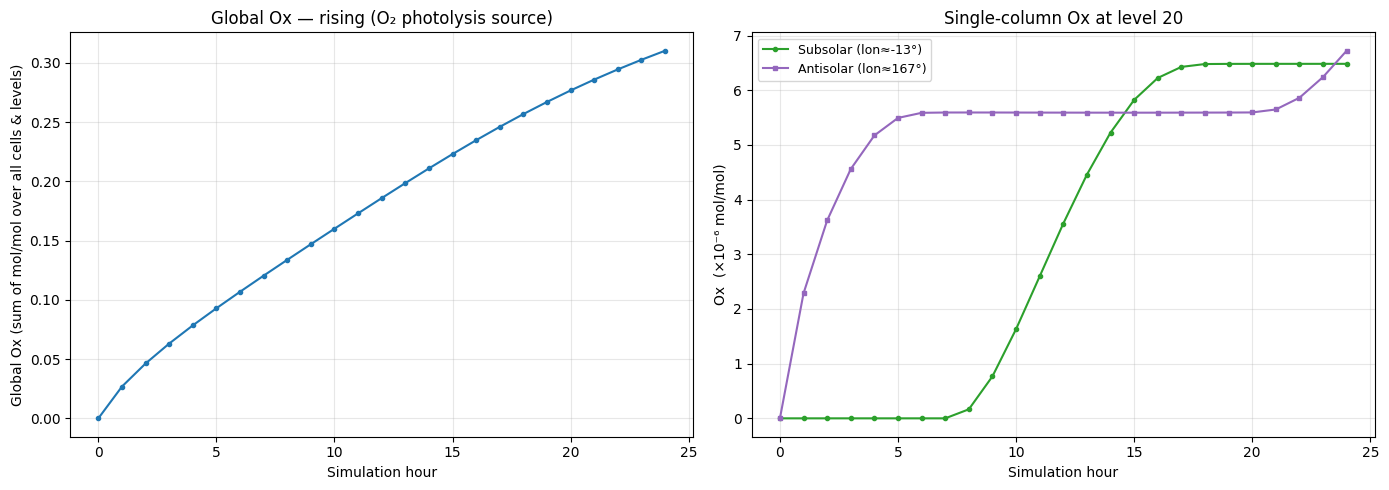

CHECK 3 — Global Ox monotonically increasing: True
  PASS ✓
CHECK 4 — Subsolar nighttime Ox drift: 0.0081% (expect < 1%)
  PASS ✓


In [5]:
# --- Global Ox vs time ---
ox_global = np.array([
    sum(ds[s][t, :, :].sum() for s in ["o3", "o", "o1d"])
    for t in range(nTimes)
])

# --- Subsolar nighttime Ox (column, single level) ---
ox_sub = np.array([
    ds["o3"][t, subsolar_idx, LEV] + ds["o"][t, subsolar_idx, LEV] + ds["o1d"][t, subsolar_idx, LEV]
    for t in range(nTimes)
])

# --- Antisolar nighttime Ox ---
ox_anti = np.array([
    ds["o3"][t, antisolar_idx, LEV] + ds["o"][t, antisolar_idx, LEV] + ds["o1d"][t, antisolar_idx, LEV]
    for t in range(nTimes)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: global Ox
ax = axes[0]
ax.plot(hours, ox_global, "o-", ms=3, color="tab:blue")
ax.set_xlabel("Simulation hour")
ax.set_ylabel("Global Ox (sum of mol/mol over all cells & levels)")
ax.set_title("Global Ox — rising (O₂ photolysis source)")
ax.grid(alpha=0.3)

# Right: single-column Ox
ax = axes[1]
ax.plot(hours, ox_sub * 1e6, "o-", ms=3, label=f"Subsolar (lon≈{lon[subsolar_idx]:.0f}°)", color="tab:green")
ax.plot(hours, ox_anti * 1e6, "s-", ms=3, label=f"Antisolar (lon≈{lon[antisolar_idx]:.0f}°)", color="tab:purple")
ax.set_xlabel("Simulation hour")
ax.set_ylabel("Ox  (×10⁻⁶ mol/mol)")
ax.set_title(f"Single-column Ox at level {LEV}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

# CHECK: global Ox should be monotonically increasing (continuous photolysis source)
diffs = np.diff(ox_global)
print(f"CHECK 3 — Global Ox monotonically increasing: {np.all(diffs > 0)}")
assert np.all(diffs > 0), "Global Ox is not monotonically increasing"
print("  PASS ✓")

# CHECK: nightside Ox is approximately constant
# Subsolar night: t=20..24
night_ox = ox_sub[20:25]
night_drift = (night_ox.max() - night_ox.min()) / night_ox.mean()
print(f"CHECK 4 — Subsolar nighttime Ox drift: {night_drift:.4%} (expect < 1%)")
assert night_drift < 0.01, f"Nighttime Ox drift too large: {night_drift:.4%}"
print("  PASS ✓")

ds.close()